/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in power
  
/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in power
  from ipykernel import kernelapp as app


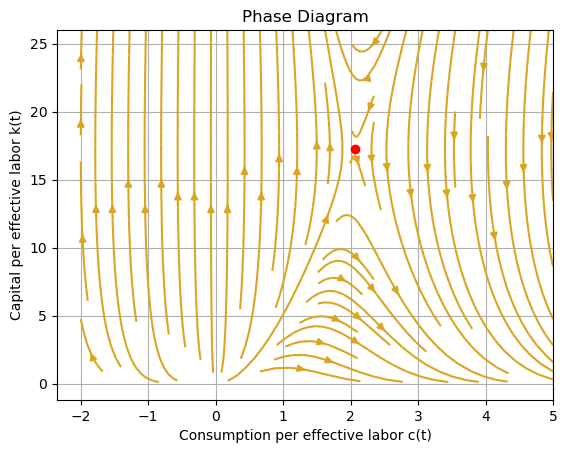

In [187]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters
alpha = 1/3
rho = 0.04
n = 0.02
g = 0.01
theta = 1

# Define the differential equations
def diff_equations(y, t):
    k, c = y
    dkdt = k**alpha - (n + g)*k - c
    dcdt = ((alpha*k**(alpha-1) - rho - theta*g) / theta) * c
    return [dkdt, dcdt]

# Set the range for k and c
c = np.linspace(-2, 5, 550)
k = np.linspace(-2, 26, 550)

# Create meshgrid 
C, K = np.meshgrid(c, k)

# Calculate growth rates at each grid point 
DK, DC = diff_equations([K, C], 0) 


# Create the streamplot
plt.streamplot(C, K, DC, DK, density=1, color='goldenrod')

# Find fixed points
fixed_points = []
for i in range(len(c)):
    for j in range(len(k)):
        if np.abs(DK[i, j]) < 0.01 and np.abs(DC[i, j]) < 0.0001:
            fixed_points.append((C[i, j], K[i, j]))

# Plot fixed points
for point in fixed_points:
    plt.plot(point[0], point[1], 'ro')
    
plt.title('Phase Diagram')
plt.xlabel('Consumption per effective labor c(t)')
plt.ylabel('Capital per effective labor k(t)')
plt.grid()
plt.show()
